In [ ]:
import sys

sys.path.append('../')
sys.path.append('../../')
sys.path.append('../../../')
import os
from dotenv import load_dotenv
load_dotenv()
tcr_toolbox_path = os.getenv('tcr_toolbox_path')
from pathlib import Path


import matplotlib as mpl
from tcr_toolbox.utils.plot_utils import startfig, set_mpl_params
mpl, mylines = set_mpl_params(mpl=mpl)
from tcr_toolbox.sequencing_analysis_PRIVATE.plate_tcr_epi_count_analysis import init_umi_count_analysis_dir, read_umi_count_tsv, filter_UMI_counts_df_dict, plot_detected_tcr_epi_plate_map, write_tcr_epi_pair_well_count_files, read_gdna_counts_csv, read_tcr_epi_pair_counts_csv, calculate_tcr_epi_pair_exp_prob_matrix, obs_tcr_epi_count_binom_sf_test, add_reactive_epi_and_tcr_co_occurrence_bool_col, add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col, plot_tcr_epi_pair_ma_plot, plot_pvalue_corrected_rank_vs_pvalue_corrected, write_reactive_pair_results, eval_performance_run, plot_and_combine_screen_pvals_stouffer, add_pair_entropy_over_plate_col
from tcr_toolbox.utils.stat_utils import normalize_counts_df_by_total_counts
from tcr_toolbox.sequencing_analysis.utils import overlap_between_ref_and_count_names
from tcr_toolbox.utils.plot_utils import set_mpl_params, plot_count_histogram 
mpl, mylines = set_mpl_params(mpl=mpl)
import numpy as np
import os
from adjustText import adjust_text
import pandas as pd
import scipy as sp
import collections

In [ ]:
project_dir = Path('/data/mel-pt-a_T200_vs_Ag200_screen-2')

In [3]:
init_umi_count_analysis_dir(project_dir)

## Preprocessing

In [3]:
counts_df_dict = read_umi_count_tsv(project_dir=project_dir,
                                    plate_name_split_location=2
                                    )

Reading plate: 10
Reading plate: 4
Reading plate: 8
Reading plate: 3
Reading plate: 2
Reading plate: 11
Reading plate: 7
Reading plate: 6
Reading plate: 13
Reading plate: 12
Reading plate: 5
Reading plate: 9
Reading plate: 1


In [ ]:
epi_umi_threshold_dict = {
        "10": 90,
    "4": 70, 
    "8": 80, 
    "3": 175,
    "2": 125, 
    "11": 125, 
    "7": 125, 
    "6": 150,
    "13": 150,
    "12": 100,
    "5": 200,
    "9": 125, 
    "1": 70,
}


tcr_umi_threshold_dict = {
       "10": 75,
    "4": 70, 
    "8": 80,
    "3": 70, 
    "2": 100, 
    "11": 100, 
    "7": 100, 
    "6": 60,
    "13": 70, 
    "12": 50,
    "5": 75,
    "9": 75,
    "1": 60,
}

In [5]:
counts_df_dict = filter_UMI_counts_df_dict(
    project_dir = project_dir, 
    counts_df_dict = counts_df_dict, 
    epi_umi_threshold=epi_umi_threshold_dict, 
    tcr_umi_threshold=tcr_umi_threshold_dict,
    min_start_fraction_of_top_umi_count=0.72, 
    min_end_fraction_of_top_umi_count = 0.12,
    num_bins=50
)

Filtering plate: 10
Number of unique epis: 254
Number of unique tcrs: 108
Filtering plate: 4
Number of unique epis: 259
Number of unique tcrs: 109
Filtering plate: 8
Number of unique epis: 260
Number of unique tcrs: 94
Filtering plate: 3
Number of unique epis: 192
Number of unique tcrs: 85
Filtering plate: 2
Number of unique epis: 247
Number of unique tcrs: 99
Filtering plate: 11
Number of unique epis: 264
Number of unique tcrs: 108
Filtering plate: 7
Number of unique epis: 252
Number of unique tcrs: 85
Filtering plate: 6
Number of unique epis: 196
Number of unique tcrs: 87
Filtering plate: 13
Number of unique epis: 194
Number of unique tcrs: 68
Filtering plate: 12
Number of unique epis: 1
Number of unique tcrs: 2
Filtering plate: 5
Number of unique epis: 192
Number of unique tcrs: 88
Filtering plate: 9
Number of unique epis: 287
Number of unique tcrs: 106
Filtering plate: 1
Number of unique epis: 267
Number of unique tcrs: 114


In [ ]:
# After individual TCR-Ag pair validation co-cultures, code can be re-run with a validating_pair_dict to color annotate dots in results plots. 
validating_pair_dict = {'epi_mel-pt-a_CCSER2_1384-tcr_9_17': True,
                               'epi_mel-pt-a_GFPT2_896-tcr_27_41': True,
                               'epi_mel-pt-a_CCSER2_1384-tcr_44_80': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_76_150': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_96_188': True, 

                               'epi_mel-pt-a_CCSER2_1384-tcr_5_7': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_40_76': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_8_11': True, 

                               'epi_mel-pt-a_GFPT2_896-tcr_18_27': True,
                               'epi_mel-pt-a_ADAM10_1753-tcr_15_24': True,

                               'epi_mel-pt-a_CCSER2_1384-tcr_103_200': True, 
                               'epi_mel-pt-a_ADAM10_1753-tcr_130_255': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_170_336': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_180_359': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_201_401': True, 

                               'epi_mel-pt-a_TNFAIP2_1709-tcr_1_1': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_10_19': True,

                               'epi_mel-pt-a_TNFAIP2_1709-tcr_30_51': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_34_60': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_60_114': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_72_139': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_101_197': True,

                               'epi_mel-pt-a_CCSER2_1384-tcr_128_252': True, 

                                'epi_mel-pt-a_XRCC6_2333-tcr_95_186': False, 
                                'epi_mel-pt-a_FUT8_1672A-tcr_69_132': False,  

                                'epi_mel-pt-a_CCSER2_1384-tcr_169_335': False,
                                'epi_mel-pt-a_TNFAIP2_1709-tcr_164_325': False, 
                                'epi_mel-pt-a_ACAP3_5-tcr_181_362': False, 
                                'epi_mel-pt-a_CBLB_629-tcr_196_392': False, 
                                'epi_mel-pt-a_CBLB_629-tcr_87_170': False, 
                                'epi_mel-pt-a_ZC3H13_1617-tcr_32_55': False,
                                'epi_mel-pt-a_MYH11_1809B-tcr_2_2': False, 
                                'epi_mel-pt-a_KAT6B_1378-tcr_21_34': False,  
                                'epi_mel-pt-a_CASP8_461A-tcr_17_26': False, 
                                'epi_mel-pt-a_NTNG1_111-tcr_5_7': False, 
                                'epi_mel-pt-a_PNPLA8-tcr_87_170': False,
                                'epi_mel-pt-a_LAMA5_2271-tcr_181_362': False              
}

In [7]:
plot_detected_tcr_epi_plate_map(project_dir = project_dir,
                                counts_df_dict = counts_df_dict,
                                validating_pair_dict = validating_pair_dict,
                                epitope_barcode_length = 18,
                                detected_fontsize = 3)

Plotting plate: 10
Plotting plate: 4
Plotting plate: 8
Plotting plate: 3
Plotting plate: 2
Plotting plate: 11
Plotting plate: 7
Plotting plate: 6
Plotting plate: 13
Plotting plate: 12
Plotting plate: 5
Plotting plate: 9
Plotting plate: 1


In [ ]:
plates_list_name = 'mel-pt-a-200-vs-200-screen-2'
plates_list = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '13']

write_tcr_epi_pair_well_count_files(project_dir = project_dir,
                                    plates_list = plates_list,
                                    plates_list_name = plates_list_name,
                                    counts_df_dict = counts_df_dict.copy(),
                                    collapse_epitope_barcode = True,
                                    epitope_barcode_length= 18,
                                    validating_pair_dict = validating_pair_dict
                                    )

Processing plate: 1
Processing plate: 2
Processing plate: 3
Processing plate: 4
Processing plate: 5
Processing plate: 6
Processing plate: 7
Processing plate: 8
Processing plate: 9
Processing plate: 10
Processing plate: 11
Processing plate: 13
Writing run-2 summary statistics...
Total # of co-culture sort wells counted: 3395


## Bulk seq QC

In [3]:
ag_bulk_file_list = [project_dir / 'bulk_seq_data/Ag/counts/7864_3_v5_GCTTGTCA-GTATGTTC_S3_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv', # 200 vs 200 run-2, Ag library transduction rep-1, screen day 1
                     project_dir / 'bulk_seq_data/Ag/counts/7864_4_v6_TGGATCGA-TATCGCAC_S4_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv', # 200 vs 200 run-2, Ag library transduction rep-2, screen day 1
                     project_dir / 'bulk_seq_data/Ag/counts/7864_5_v8_GACCTGAA-CTCACCAA_S5_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv', # 200 vs 200 run-2, Ag library transduction rep-2, screen day 2
]

tcr_bulk_file_list = [project_dir / 'bulk_seq_data/TCR/counts/7864_1_v1_TTACAGGA-GCTTGTCA_S1_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv', # 200 vs 200 run-2, TCR library transduction rep-1, screen day 1
                      project_dir / 'bulk_seq_data/TCR/counts/7864_2_v2_GGCATTCT-CAAGCTAG_S2_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv', # 200 vs 200 run-2, TCR library transduction rep-2, screen day 1
]

In [4]:
bulk_project_dir = Path(project_dir) / 'bulk_seq_data' /'TCR'

In [ ]:
name_split_location = 2
for count_file in tcr_bulk_file_list:
    print(count_file.name)
    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file='/references/T200_Ag200/T200_beta.fa',
        library_ref_id_list=None,
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        log10 = True, 
        xlabel="Number of reads per transcript",
        percentile_ratio_filter_threshold = 1.75, 
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=30,
        w=6.25,
        h=6.25,
    )
    print("\n")

7864_1_v1_TTACAGGA-GCTTGTCA_S1_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv
# intersecting: 181
# diff: 2
# union: 183
Sensitivity: 98.91% (181/183 reference names found in counts)
refs not in count names: {'189_377', '143_275'}
count names not in ref subset: set()
95th percentile: 3895.20 | 5th percentile: 516.20 | 95th/5th ratio: 7.55


7864_2_v2_GGCATTCT-CAAGCTAG_S2_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv
# intersecting: 180
# diff: 3
# union: 183
Sensitivity: 98.36% (180/183 reference names found in counts)
refs not in count names: {'189_377', '143_275', '177_349'}
count names not in ref subset: set()
95th percentile: 3171.00 | 5th percentile: 331.20 | 95th/5th ratio: 9.57




In [7]:
bulk_project_dir = Path(project_dir) / 'bulk_seq_data' /'Ag'

In [ ]:
name_split_location = 2
for count_file in ag_bulk_file_list:
    print(count_file.name)
    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file='/references/T200_Ag200/Ag200.fa',
        library_ref_id_list=None,
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        log10 = True, 
        xlabel="Number of reads per transcript",
        percentile_ratio_filter_threshold = 1.75, 
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=80,
        w=6.25,
        h=6.25,
    )
    print("\n")

7864_3_v5_GCTTGTCA-GTATGTTC_S3_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv
# intersecting: 400
# diff: 3
# union: 403
Sensitivity: 99.26% (400/403 reference names found in counts)
refs not in count names: {'p20_stuffer', 'GLC', 'NYESO1'}
count names not in ref subset: set()
95th percentile: 2116.65 | 5th percentile: 348.65 | 95th/5th ratio: 6.07


7864_4_v6_TGGATCGA-TATCGCAC_S4_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv
# intersecting: 401
# diff: 2
# union: 403
Sensitivity: 99.50% (401/403 reference names found in counts)
refs not in count names: {'GLC', 'NYESO1'}
count names not in ref subset: set()
95th percentile: 2419.25 | 5th percentile: 451.45 | 95th/5th ratio: 5.36


7864_5_v8_GACCTGAA-CTCACCAA_S5_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv
# intersecting: 401
# diff: 2
# union: 403
Sensitivity: 99.50% (401/403 reference names found in counts)
refs not in count names: {'GLC', 'NYESO1'}
count names not in ref subset: set()
9

In [9]:
# 200 vs 200 run-2, Ag library transduction rep-1, screen day 1
epi_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7864_3_v5_GCTTGTCA-GTATGTTC_S3_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                          count_file_ref_name_col = 'reference_name',
                                          collapse_epitope_barcode = True,
                                          epitope_barcode_length = 18
                                          )

In [10]:
normalized_epi_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df_1, count_col = 'read_count')

In [11]:
# 200 vs 200 run-2, Ag library transduction rep-2, screen day 1
epi_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7864_4_v6_TGGATCGA-TATCGCAC_S4_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            collapse_epitope_barcode = True,
                                            epitope_barcode_length = 18
                                            )

In [12]:
normalized_epi_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df_2, count_col = 'read_count')

In [13]:
# 200 vs 200 run-2, Ag library transduction rep-2, screen day 2
epi_bulk_counts_df_2_d2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7864_5_v8_GACCTGAA-CTCACCAA_S5_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            collapse_epitope_barcode = True,
                                            epitope_barcode_length = 18
                                            )

In [14]:
normalized_epi_bulk_counts_df_2_d2 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df_2_d2, count_col = 'read_count')

In [ ]:
print(len(set(normalized_epi_bulk_counts_df_1.index).union(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_1.index).intersection(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_1.index).difference(set(normalized_epi_bulk_counts_df_2.index))))
normalized_epi_bulk_counts_df = normalized_epi_bulk_counts_df_1.merge(normalized_epi_bulk_counts_df_2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between Ag200-rep-1 and Ag200-rep-2:',
      normalized_epi_bulk_counts_df['read_count_1'].corr(normalized_epi_bulk_counts_df['read_count_2'],
                                                         method='spearman'))
normalized_epi_bulk_counts_df['read_count'] = normalized_epi_bulk_counts_df.loc[:,['read_count_1', 'read_count_2']].mean(axis=1)

ax, fig, gs  = startfig(6, 6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_epi_bulk_counts_df['read_count_1'],
                                                      normalized_epi_bulk_counts_df['read_count_2'],
                                                      normalized_epi_bulk_counts_df.index):
    if read_count_1 / read_count_2 > 1.75 or read_count_1 / read_count_2 < 1/1.75:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_epi_bulk_counts_df['read_count_1'], normalized_epi_bulk_counts_df['read_count_2'], color = color_list)

adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

normalized_epi_bulk_counts_df.drop(['read_count_1', 'read_count_2'], axis=1, inplace=True)
normalized_epi_bulk_counts_df['read_count'].isna().any()
ax.set_xlabel("Ag200 transduction rep-1", fontsize = 7)
ax.set_ylabel("Ag200 transduction rep-2 day-1", fontsize = 7)
ax.tick_params('both', labelsize = 7)

201
201
0
Spearman’s rank correlation coefficient between Ag200-rep-2 day-1 and Ag200-rep-2 day-2: 0.9509473597102625


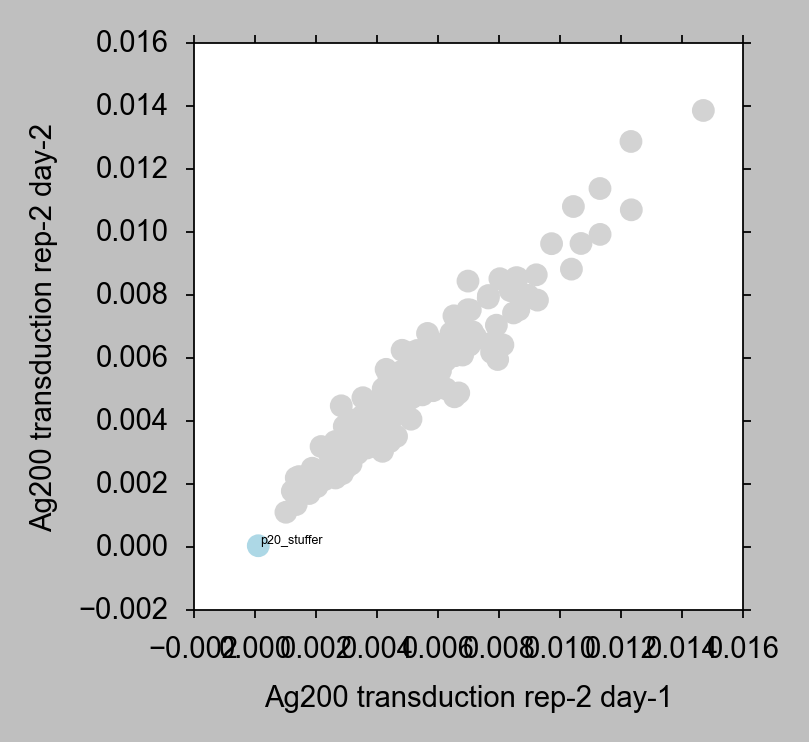

In [16]:
print(len(set(normalized_epi_bulk_counts_df_2_d2.index).union(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_2_d2.index).intersection(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_2_d2.index).difference(set(normalized_epi_bulk_counts_df_2.index))))
normalized_epi_bulk_counts_df_test = normalized_epi_bulk_counts_df_2_d2.merge(normalized_epi_bulk_counts_df_2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between Ag200-rep-2 day-1 and Ag200-rep-2 day-2:',
      normalized_epi_bulk_counts_df_test['read_count_1'].corr(normalized_epi_bulk_counts_df_test['read_count_2'],
                                                         method='spearman'))
normalized_epi_bulk_counts_df_test['read_count'] = normalized_epi_bulk_counts_df_test.loc[:,['read_count_1', 'read_count_2']].mean(axis=1)

ax, fig, gs  = startfig(6, 6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_epi_bulk_counts_df_test['read_count_1'],
                                                      normalized_epi_bulk_counts_df_test['read_count_2'],
                                                      normalized_epi_bulk_counts_df_test.index):
    if read_count_1 / read_count_2 > 1.9 or read_count_1 / read_count_2 < 1/1.9:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_epi_bulk_counts_df_test['read_count_1'], normalized_epi_bulk_counts_df_test['read_count_2'], color = color_list)

adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

ax.tick_params('both', labelsize = 7)
ax.set_xlabel("Ag200 transduction rep-2 day-1", fontsize = 7)
ax.set_ylabel("Ag200 transduction rep-2 day-2", fontsize = 7)
ax.tick_params('both', labelsize = 7)

In [17]:
# 200 vs 200 run-2, TCR library transduction rep-1, screen day 1
tcr_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7864_1_v1_TTACAGGA-GCTTGTCA_S1_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            )

In [18]:
normalized_tcr_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_1, count_col = 'read_count')

In [19]:
# 200 vs 200 run-2, TCR library transduction rep-2, screen day 1
tcr_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7864_2_v2_GGCATTCT-CAAGCTAG_S2_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            )

In [20]:
normalized_tcr_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_2, count_col = 'read_count')

In [21]:
print(len(set(normalized_tcr_bulk_counts_df_1.index).union(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).intersection(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).difference(set(normalized_tcr_bulk_counts_df_2.index))))
normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df_1.merge(normalized_tcr_bulk_counts_df_2, on = 'reference_name', suffixes = ('_1', '_2'))
print('Spearman’s rank correlation coefficient between T200-1 and T200-2:', normalized_tcr_bulk_counts_df['read_count_1'].corr(normalized_tcr_bulk_counts_df['read_count_2'], method = 'spearman'))
normalized_tcr_bulk_counts_df['read_count'] = normalized_tcr_bulk_counts_df.loc[:, ['read_count_1', 'read_count_2']].mean(axis = 1)
normalized_tcr_bulk_counts_df.drop(['read_count_1', 'read_count_2'], axis = 1, inplace = True)
normalized_tcr_bulk_counts_df['read_count'].isna().any()

181
180
1
Spearman’s rank correlation coefficient between T200-1 and T200-2: 0.8396705846768149


np.False_

## Mel-Pt-A 200 vs 200 screen 2 analysis

In [22]:
pair_count_matrix_df = read_tcr_epi_pair_counts_csv(pair_count_matrix_csv = project_dir / 'outs/run-2/pair_count_matrix_df_run-2.csv')

In [23]:
alpha = 0.05

In [ ]:
exp_pair_prob_matrix_df, pair_count_matrix_df = calculate_tcr_epi_pair_exp_prob_matrix(
                                                                                        pair_count_matrix_df=pair_count_matrix_df,
                                                                                        normalized_epitope_bulk_counts_df=normalized_epi_bulk_counts_df,
                                                                                        normalized_tcr_bulk_counts_df=normalized_tcr_bulk_counts_df,
                                                                                        bulk_epitope_count_col='read_count',
                                                                                        bulk_tcr_count_col='read_count',
                                                                                        normalize_using_plate=False,
                                                                                      )

In [25]:
pair_fold_changes_df = obs_tcr_epi_count_binom_sf_test(project_dir = project_dir,
                                                       pair_count_matrix_df = pair_count_matrix_df,
                                                       exp_pair_prob_matrix_df = exp_pair_prob_matrix_df,
                                                       plates_list_name = plates_list_name,
                                                       validating_pair_dict = validating_pair_dict,
                                                       fdr_correction = True,
                                                       alpha = alpha,
                                                       normalize_total_called_pairs = False,
                                                       normalize_total_wells_with_detected_pair = True,
                                                       sort_fold_change = False,
                                                       sort_pvalue = True
                                                       )

2977 TCR-epitope pairs have non-zero well counts of 34228 tested TCR-epitope pairs


In [26]:
pair_fold_changes_df = add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col(project_dir = project_dir,
                                                                                  plates_list_name = plates_list_name,
                                                                                  pair_fold_changes_df = pair_fold_changes_df,
                                                                                  epi_transcript_ratio = 0.6,
                                                                                  tcr_transcript_ratio = 0.6
                                                                                  )

In [28]:
pair_fold_changes_df = add_pair_entropy_over_plate_col(pair_fold_changes_df = pair_fold_changes_df, project_dir = project_dir)

In [29]:
write_reactive_pair_results(pair_fold_changes_df = pair_fold_changes_df,
                            project_dir = project_dir,
                            plates_list_name = plates_list_name,
                            validating_pair_dict = validating_pair_dict
                            )

In [30]:
pair_fold_changes_df.to_excel(project_dir / 'outs' / plates_list_name / f'pair_fold_changes_df_{plates_list_name}.xlsx')
pair_fold_changes_df = pd.read_excel(Path(project_dir) / "outs" / plates_list_name / f"pair_fold_changes_df_{plates_list_name}.xlsx", index_col = 0)

In [31]:
pair_fold_changes_df['Fold_change'].max()

3559.378759096851

In [ ]:
plot_tcr_epi_pair_ma_plot(pair_fold_changes_df = pair_fold_changes_df,
                          title = plates_list_name,
                          xlim_max = 0.0002,
                          xticks_list = list(np.arange(-0.00001, 0.0002, 0.0001)),
                          xlim_min = -0.00001,
                          ylim_max = 900,
                          save_dir = project_dir / 'outs'/ plates_list_name,
                          custom_pair_color_dict = None,
                          plot_filter_only_supported_co_occurrence = True,
                          plot_reactive_pair_co_occurrence = False,
                          annotate = True,
                          annotation_fontsize = 2.5,
                          w = 11,
                          h = 11
                          )

In [33]:
plot_tcr_epi_pair_ma_plot(pair_fold_changes_df = pair_fold_changes_df,
                          title = plates_list_name,
                          xlim_max = 0.0002,
                          xticks_list = list(np.arange(-0.00001, 0.0002, 0.0001)),
                          xlim_min = -0.00001,
                          ylim_max = 900,
                          save_dir = project_dir / 'outs' / plates_list_name,
                          custom_pair_color_dict = None,
                          plot_filter_only_supported_co_occurrence = True,
                          plot_reactive_pair_co_occurrence = False,
                          annotate = False,
                          #annotation_fontsize = 2.5,
                          w = 11,
                          h = 11
                          )

In [34]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(pair_fold_changes_df = pair_fold_changes_df,
                                               save_dir = project_dir / 'outs' / plates_list_name,
                                               title = plates_list_name,
                                               xlim_max = 120,
                                               xlim_min = -5,
                                               ylim_max = 100,
                                               ylim_min = -2.5,
                                               adj_pval_alpha = None,
                                               filter_significant_with_more_than_one_epi = True,
                                               custom_pair_color_dict = None,
                                               annotate = True
                                               )

In [35]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(pair_fold_changes_df = pair_fold_changes_df,
                                               save_dir = project_dir / 'outs'/ plates_list_name,
                                               title = plates_list_name,
                                               xlim_max = 120,
                                               xlim_min = -5,
                                               ylim_max = 100,
                                               ylim_min = -2.5,
                                               adj_pval_alpha = None,
                                               filter_significant_with_more_than_one_epi = True,
                                               custom_pair_color_dict = None,
                                               annotate = False
                                               )

## Compare fold-enrichment CCSER2mut-reactive TCRs screen 1 vs screen 2 

In [36]:
alpha = 0.05

In [ ]:
plot_and_combine_screen_pvals_stouffer(screen_output_run_dir_dict =
                                       {'screen-1': '/data/mel-pt-a_T200_vs_Ag200_screen-1/outs/mel-pt-a-200-vs-200-screen-1',
                                        'screen-2': '/data/mel-pt-a_T200_vs_Ag200_screen-2/outs/mel-pt-a-200-vs-200-screen-2'},
                                       adj_pval_alpha = alpha,
                                       project_dir = project_dir,
                                       zoom_adj_pval_alpha = 0.000001,
                                       zoom_log_fold = 200,
                                       validating_pair_dict = validating_pair_dict,
                                       subset_epi_list = ['epi_mel-pt-a_CCSER2_1384'],
                                       only_plot_validating=True,
                                       w = 5, 
                                       h = 5
                                       )

3 [-0.63346224  0.67346291]
4 [-0.41493359  0.5468412 ]
10 [ 0.85416023 -0.11464192]
11 [ 0.23471444 -0.11924548]
5 [-0.61321115  0.50515656]
7 [-0.41248642  0.78745361]
3 [0.73435545 0.37722762]
5 [-0.52480084 -0.92436068]
5 [0.89880461 0.28129002]
10 [-0.15952485 -0.48954547]
5 [-0.21912125  0.76296297]
8 [0.21863874 0.59721498]
11 [-0.05283611 -0.91200076]
4 [-0.83803458  0.11121716]
5 [-0.76373432 -0.07140728]
4 [ 0.97005225 -0.18731132]
8 [-0.08001211 -0.70660523]
4 [ 0.80815536 -0.72220651]
5 [-0.14031575  0.15221658]


## Mel-Pt-A 200 vs 200 combined screens analysis

In [ ]:
project_dir = Path('/data/mel-pt-a_200_vs_200_combined')

In [41]:
counts_df_dict = read_umi_count_tsv(project_dir=project_dir,
                                    plate_name_split_location=2
                                    )

Reading plate: 10
Reading plate: 1-3
Reading plate: 4
Reading plate: 8
Reading plate: 1-11
Reading plate: 1-9
Reading plate: 1-5
Reading plate: 3
Reading plate: 1-8
Reading plate: 1-4
Reading plate: 2
Reading plate: 11
Reading plate: 1-2
Reading plate: 1-7
Reading plate: 1-1
Reading plate: 1-6
Reading plate: 1-13
Reading plate: 1-10
Reading plate: 7
Reading plate: 6
Reading plate: 13
Reading plate: 12
Reading plate: 5
Reading plate: 1-12
Reading plate: 9
Reading plate: 1


In [ ]:
epi_umi_threshold_dict = {
    "1-3": 250, 
    "1-11": 200, 
    "1-9": 150,
    "1-5": 150,
    "1-8": 200,
    "1-4": 200, 
    "1-2": 200,
    "1-7": 150,
    "1-1": 200,
    "1-6": 200, 
    "1-13": 150, 
    "1-10": 150,
    "1-12": 175,
        "10": 90,
    "4": 70, 
    "8": 80, 
    "3": 175,
    "2": 125, 
    "11": 125,
    "7": 125, 
    "6": 150,
    "13": 150,
    "12": 100,
    "5": 200,
    "9": 125, 
    "1": 70,
}


tcr_umi_threshold_dict = {
    "1-3": 150, 
    "1-11": 100, 
    "1-9": 75,
    "1-5": 100,
    "1-8": 60,
    "1-4": 200,
    "1-2": 200,
    "1-7": 60,
    "1-1": 100,
    "1-6": 100,
    "1-13": 75, 
    "1-10": 70, 
    "1-12": 75, 
       "10": 75,
    "4": 70, 
    "8": 80, 
    "3": 70, 
    "2": 100, 
    "11": 100, 
    "7": 100, 
    "6": 60,
    "13": 70, 
    "12": 50,
    "5": 75,
    "9": 75,
    "1": 60,
}

In [43]:
counts_df_dict = filter_UMI_counts_df_dict(
    project_dir = project_dir, 
    counts_df_dict = counts_df_dict, 
    epi_umi_threshold=epi_umi_threshold_dict, 
    tcr_umi_threshold=tcr_umi_threshold_dict,
    min_start_fraction_of_top_umi_count=0.72, 
    min_end_fraction_of_top_umi_count = 0.12,
    num_bins=50
)

Filtering plate: 10
Number of unique epis: 254
Number of unique tcrs: 108
Filtering plate: 1-3
Number of unique epis: 150
Number of unique tcrs: 69
Filtering plate: 4
Number of unique epis: 259
Number of unique tcrs: 109
Filtering plate: 8
Number of unique epis: 260
Number of unique tcrs: 94
Filtering plate: 1-11
Number of unique epis: 189
Number of unique tcrs: 99
Filtering plate: 1-9
Number of unique epis: 194
Number of unique tcrs: 100
Filtering plate: 1-5
Number of unique epis: 179
Number of unique tcrs: 72
Filtering plate: 3
Number of unique epis: 192
Number of unique tcrs: 85
Filtering plate: 1-8
Number of unique epis: 192
Number of unique tcrs: 116
Filtering plate: 1-4
Number of unique epis: 100
Number of unique tcrs: 70
Filtering plate: 2
Number of unique epis: 247
Number of unique tcrs: 99
Filtering plate: 11
Number of unique epis: 264
Number of unique tcrs: 108
Filtering plate: 1-2
Number of unique epis: 98
Number of unique tcrs: 66
Filtering plate: 1-7
Number of unique epis:

In [44]:
plot_detected_tcr_epi_plate_map(
    project_dir=project_dir, counts_df_dict=counts_df_dict, validating_pair_dict=validating_pair_dict, epitope_barcode_length=18, detected_fontsize=3
)

Plotting plate: 10
Plotting plate: 1-3
Plotting plate: 4
Plotting plate: 8
Plotting plate: 1-11
Plotting plate: 1-9
Plotting plate: 1-5
Plotting plate: 3
Plotting plate: 1-8
Plotting plate: 1-4
Plotting plate: 2
Plotting plate: 11
Plotting plate: 1-2
Plotting plate: 1-7
Plotting plate: 1-1
Plotting plate: 1-6
Plotting plate: 1-13
Plotting plate: 1-10
Plotting plate: 7
Plotting plate: 6
Plotting plate: 13
Plotting plate: 12
Plotting plate: 5
Plotting plate: 1-12
Plotting plate: 9
Plotting plate: 1


In [ ]:
plates_list_name = "mel-pt-a_200_vs_200_combined"

In [46]:
plates_list = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '13', '1-7', '1-8', '1-9','1-10', '1-11', '1-12', '1-13']

write_tcr_epi_pair_well_count_files(
    project_dir=project_dir,
    plates_list=plates_list,
    plates_list_name=plates_list_name,
    counts_df_dict=counts_df_dict.copy(),
    collapse_epitope_barcode=True,
    epitope_barcode_length=18,
    validating_pair_dict=validating_pair_dict,
)

Processing plate: 1
Processing plate: 2
Processing plate: 3
Processing plate: 4
Processing plate: 5
Processing plate: 6
Processing plate: 7
Processing plate: 8
Processing plate: 9
Processing plate: 10
Processing plate: 11
Processing plate: 13
Processing plate: 1-7
Processing plate: 1-8
Processing plate: 1-9
Processing plate: 1-10
Processing plate: 1-11
Processing plate: 1-12
Processing plate: 1-13
Writing 200vs200-r1-2-r2 summary statistics...
Total # of co-culture sort wells counted: 5214


In [ ]:
project_dir = Path('/data/mel-pt-a_T200_vs_Ag200_screen-1')

In [48]:
# 200 vs 200 run-1, Ag library
epi_bulk_counts_df = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7767_16_1-Ag200-2-bulk_GACCTGAA-CTCACCAA_S16_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                          count_file_ref_name_col = 'reference_name',
                                          collapse_epitope_barcode = True,
                                          epitope_barcode_length = 18
                                          )

In [49]:
normalized_epi_bulk_counts_df_r1_2 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df, count_col = 'read_count')

In [50]:
# 200 vs 200 run-1, TCR library transduction rep-1
tcr_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7767_14_1-T200-1-bulk_TTACAGGA-GCTTGTCA_S14_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                         count_file_ref_name_col = 'reference_name',
                                         )

In [51]:
normalized_tcr_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_1, count_col = 'read_count')

In [52]:
# 200 vs 200 run-1, TCR library transduction rep-2
tcr_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7767_15_1-T200-2-bulk_GGCATTCT-CAAGCTAG_S15_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                         count_file_ref_name_col = 'reference_name',
                                         )

In [53]:
normalized_tcr_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_2, count_col = 'read_count')

In [54]:
print(len(set(normalized_tcr_bulk_counts_df_1.index).union(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).intersection(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).difference(set(normalized_tcr_bulk_counts_df_2.index))))
normalized_tcr_bulk_counts_df_r1_2 = normalized_tcr_bulk_counts_df_1.merge(normalized_tcr_bulk_counts_df_2, on = 'reference_name', suffixes = ('_1', '_2'))
print('Spearman’s rank correlation coefficient between T200-1 and T200-2:', normalized_tcr_bulk_counts_df_r1_2['read_count_1'].corr(normalized_tcr_bulk_counts_df_r1_2['read_count_2'], method = 'spearman'))
normalized_tcr_bulk_counts_df_r1_2['read_count'] = normalized_tcr_bulk_counts_df_r1_2.loc[:, ['read_count_1', 'read_count_2']].mean(axis = 1)
normalized_tcr_bulk_counts_df_r1_2.drop(['read_count_1', 'read_count_2'], axis = 1, inplace = True)
normalized_tcr_bulk_counts_df_r1_2['read_count'].isna().any()

180
180
0
Spearman’s rank correlation coefficient between T200-1 and T200-2: 0.8152984853895983


np.False_

In [ ]:
project_dir = Path('/data/mel-pt-a_T200_vs_Ag200_screen-2')

In [56]:
# # 200 vs 200 run-2, Ag library transduction rep-1, screen day 1
epi_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7864_3_v5_GCTTGTCA-GTATGTTC_S3_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                          count_file_ref_name_col = 'reference_name',
                                          collapse_epitope_barcode = True,
                                          epitope_barcode_length = 18
                                          )

In [57]:
normalized_epi_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df_1, count_col = 'read_count')

In [58]:
# 200 vs 200 run-2, Ag library transduction rep-2, screen day 1
epi_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7864_4_v6_TGGATCGA-TATCGCAC_S4_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            collapse_epitope_barcode = True,
                                            epitope_barcode_length = 18
                                            )

In [59]:
normalized_epi_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df_2, count_col = 'read_count')

In [ ]:
print(len(set(normalized_epi_bulk_counts_df_1.index).union(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_1.index).intersection(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_1.index).difference(set(normalized_epi_bulk_counts_df_2.index))))
normalized_epi_bulk_counts_df_r2 = normalized_epi_bulk_counts_df_1.merge(normalized_epi_bulk_counts_df_2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between Ag200-rep-1 and Ag200-rep-2:',
      normalized_epi_bulk_counts_df_r2['read_count_1'].corr(normalized_epi_bulk_counts_df_r2['read_count_2'],
                                                         method='spearman'))
normalized_epi_bulk_counts_df_r2['read_count'] = normalized_epi_bulk_counts_df_r2.loc[:,['read_count_1', 'read_count_2']].mean(axis=1)

ax, fig, gs  = startfig(6,6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_epi_bulk_counts_df_r2['read_count_1'],
                                                      normalized_epi_bulk_counts_df_r2['read_count_2'],
                                                      normalized_epi_bulk_counts_df_r2.index):
    if read_count_1 / read_count_2 > 1.75 or read_count_1 / read_count_2 < 1/1.75:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_epi_bulk_counts_df_r2['read_count_1'], normalized_epi_bulk_counts_df_r2['read_count_2'], color = color_list, s = 8)
ax.tick_params('both', labelsize = 7)
adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

normalized_epi_bulk_counts_df_r2.drop(['read_count_1', 'read_count_2'], axis=1, inplace=True)
normalized_epi_bulk_counts_df_r2['read_count'].isna().any()
ax.set_xlabel("Ag200 transduction rep-1", fontsize = 7)
ax.set_ylabel("Ag200 transduction rep-2 day-1", fontsize = 7)
ax.tick_params('both', labelsize = 7)

In [61]:
weights = [1819, 3395]
print(sum(weights))

5214


In [ ]:
print(len(set(normalized_epi_bulk_counts_df_r1_2.index).union(set(normalized_epi_bulk_counts_df_r2.index))))
print(len(set(normalized_epi_bulk_counts_df_r1_2.index).intersection(set(normalized_epi_bulk_counts_df_r2.index))))
print(len(set(normalized_epi_bulk_counts_df_r1_2.index).difference(set(normalized_epi_bulk_counts_df_r2.index))))
normalized_epi_bulk_counts_df = normalized_epi_bulk_counts_df_r1_2.merge(normalized_epi_bulk_counts_df_r2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between Ag200-run-1-2 and Ag200-run-2:',
      normalized_epi_bulk_counts_df['read_count_1'].corr(normalized_epi_bulk_counts_df['read_count_2'],
                                                         method='spearman'))
normalized_epi_bulk_counts_df['read_count'] = normalized_epi_bulk_counts_df.loc[:,['read_count_1', 'read_count_2']].dot(weights) / sum(weights)

ax, fig, gs  = startfig(6,6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_epi_bulk_counts_df['read_count_1'],
                                                      normalized_epi_bulk_counts_df['read_count_2'],
                                                      normalized_epi_bulk_counts_df.index):
    if read_count_1 / read_count_2 > 1.75 or read_count_1 / read_count_2 < 1/1.75:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_epi_bulk_counts_df['read_count_1'], normalized_epi_bulk_counts_df['read_count_2'], color = color_list, s = 8)
ax.tick_params('both', labelsize = 7)
adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

normalized_epi_bulk_counts_df.drop(['read_count_1', 'read_count_2'], axis=1, inplace=True)
normalized_epi_bulk_counts_df['read_count'].isna().any()
ax.set_xlabel("Ag200 transduction run-1-2", fontsize = 7)
ax.set_ylabel("Ag200 transduction run-2 rep-combined", fontsize = 7)
ax.tick_params('both', labelsize = 7)

In [63]:
# 200 vs 200 run-2, TCR library transduction rep-1, screen day 1
tcr_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7864_1_v1_TTACAGGA-GCTTGTCA_S1_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            )

In [64]:
normalized_tcr_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_1, count_col = 'read_count')

In [65]:
# 200 vs 200 run-2, TCR library transduction rep-2, screen day 1
tcr_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7864_2_v2_GGCATTCT-CAAGCTAG_S2_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            )

In [66]:
normalized_tcr_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_2, count_col = 'read_count')

In [67]:
print(len(set(normalized_tcr_bulk_counts_df_1.index).union(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).intersection(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).difference(set(normalized_tcr_bulk_counts_df_2.index))))
normalized_tcr_bulk_counts_df_r2 = normalized_tcr_bulk_counts_df_1.merge(normalized_tcr_bulk_counts_df_2, on = 'reference_name', suffixes = ('_1', '_2'))
print('Spearman’s rank correlation coefficient between T200-1 and T200-2:', normalized_tcr_bulk_counts_df_r2['read_count_1'].corr(normalized_tcr_bulk_counts_df_r2['read_count_2'], method = 'spearman'))
normalized_tcr_bulk_counts_df_r2['read_count'] = normalized_tcr_bulk_counts_df_r2.loc[:, ['read_count_1', 'read_count_2']].mean(axis = 1)
normalized_tcr_bulk_counts_df_r2.drop(['read_count_1', 'read_count_2'], axis = 1, inplace = True)
normalized_tcr_bulk_counts_df_r2['read_count'].isna().any()

181
180
1
Spearman’s rank correlation coefficient between T200-1 and T200-2: 0.8396705846768149


np.False_

180
180
0
Spearman’s rank correlation coefficient between T200-run-1-2 and T200-run-2: 0.9816516970688395


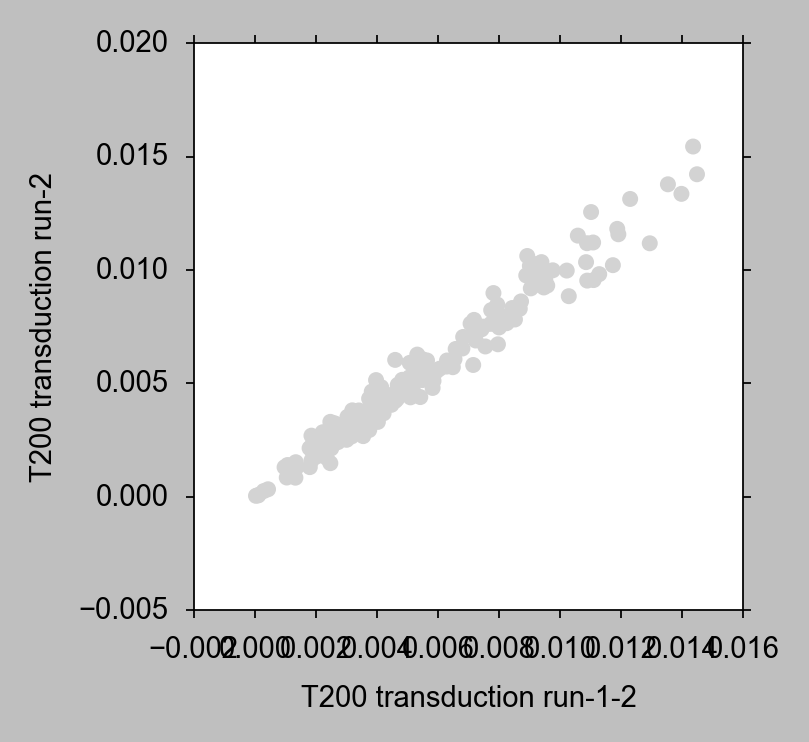

In [68]:
print(len(set(normalized_tcr_bulk_counts_df_r1_2.index).union(set(normalized_tcr_bulk_counts_df_r2.index))))
print(len(set(normalized_tcr_bulk_counts_df_r1_2.index).intersection(set(normalized_tcr_bulk_counts_df_r2.index))))
print(len(set(normalized_tcr_bulk_counts_df_r1_2.index).difference(set(normalized_tcr_bulk_counts_df_r2.index))))
normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df_r1_2.merge(normalized_tcr_bulk_counts_df_r2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between T200-run-1-2 and T200-run-2:',
      normalized_tcr_bulk_counts_df['read_count_1'].corr(normalized_tcr_bulk_counts_df['read_count_2'],
                                                         method='spearman'))
normalized_tcr_bulk_counts_df['read_count'] = normalized_tcr_bulk_counts_df.loc[:,['read_count_1', 'read_count_2']].dot(weights) / sum(weights)

ax, fig, gs  = startfig(6,6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_tcr_bulk_counts_df['read_count_1'],
                                                      normalized_tcr_bulk_counts_df['read_count_2'],
                                                      normalized_tcr_bulk_counts_df.index):
    if read_count_1 / read_count_2 > 1.75 or read_count_1 / read_count_2 < 1/1.75:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_tcr_bulk_counts_df['read_count_1'], normalized_tcr_bulk_counts_df['read_count_2'], color = color_list, s = 8)
ax.tick_params('both', labelsize = 7)
adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

normalized_tcr_bulk_counts_df.drop(['read_count_1', 'read_count_2'], axis=1, inplace=True)
normalized_tcr_bulk_counts_df['read_count'].isna().any()
ax.set_xlabel("T200 transduction run-1-2", fontsize = 7)
ax.set_ylabel("T200 transduction run-2", fontsize = 7)
ax.tick_params('both', labelsize = 7)

In [ ]:
project_dir = Path('/data/mel-pt-a_200_vs_200_combined')

In [ ]:
pair_count_matrix_df = read_tcr_epi_pair_counts_csv(pair_count_matrix_csv=Path(project_dir) / "outs" / plates_list_name / f"pair_count_matrix_df_{plates_list_name}.csv")
exp_pair_prob_matrix_df, pair_count_matrix_df = calculate_tcr_epi_pair_exp_prob_matrix(
    pair_count_matrix_df=pair_count_matrix_df,
    normalized_epitope_bulk_counts_df=normalized_epi_bulk_counts_df,
    normalized_tcr_bulk_counts_df=normalized_tcr_bulk_counts_df,
    bulk_epitope_count_col="read_count",
    bulk_tcr_count_col="read_count",
    normalize_using_plate=False,
)

In [ ]:
alpha = 0.001
pair_fold_changes_df = obs_tcr_epi_count_binom_sf_test(
    project_dir=project_dir,
    pair_count_matrix_df=pair_count_matrix_df,
    exp_pair_prob_matrix_df=exp_pair_prob_matrix_df,
    plates_list_name=plates_list_name,
    validating_pair_dict = validating_pair_dict,
    fdr_correction=True,
    alpha=alpha,
    normalize_total_called_pairs=False,
    normalize_total_wells_with_detected_pair=True,
    sort_fold_change=False,
    sort_pvalue=True,
)

4371 TCR-epitope pairs have non-zero well counts of 34825 tested TCR-epitope pairs


In [73]:
pair_fold_changes_df = add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col(
    project_dir=project_dir, plates_list_name=plates_list_name, pair_fold_changes_df=pair_fold_changes_df, 
    epi_transcript_ratio=0.7, tcr_transcript_ratio=0.7
)

In [74]:
pair_fold_changes_df = add_pair_entropy_over_plate_col(pair_fold_changes_df = pair_fold_changes_df, project_dir = project_dir)

In [75]:
write_reactive_pair_results(
    pair_fold_changes_df=pair_fold_changes_df,
    project_dir=project_dir,
    plates_list_name=plates_list_name,
    validating_pair_dict = validating_pair_dict
)

In [76]:
pair_fold_changes_df.to_excel(Path(project_dir) / "outs" / plates_list_name / f"pair_fold_changes_df_{plates_list_name}.xlsx")

In [ ]:
plot_tcr_epi_pair_ma_plot(pair_fold_changes_df = pair_fold_changes_df,
                          title = plates_list_name,
                          xlim_max = 0.0001,
                          xticks_list = list(np.arange(-0.00001, 0.0001, 0.00005)),
                          xlim_min = -0.00001, 
                          ylim_max = 700,
                          save_dir = project_dir / 'outs' / plates_list_name,
                          custom_pair_color_dict = None,
                          plot_filter_only_supported_co_occurrence = True,
                          plot_reactive_pair_co_occurrence = False,
                          annotate = True,
                          annotation_fontsize = 2.5,
                          w = 6,
                          h = 6
                          )

In [78]:
plot_tcr_epi_pair_ma_plot(pair_fold_changes_df = pair_fold_changes_df,
                          title = plates_list_name,
                          xlim_max = 0.0001,
                          xticks_list = list(np.arange(-0.00001, 0.0001, 0.00005)),
                          xlim_min = -0.00001,
                          ylim_max = 700,
                          save_dir = project_dir / 'outs' / plates_list_name,
                          custom_pair_color_dict = None,
                          plot_filter_only_supported_co_occurrence = True,
                          plot_reactive_pair_co_occurrence = False,
                          annotate = False,
                          annotation_fontsize = 2.5,
                          w = 6,
                          h = 6
                          )

In [79]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(pair_fold_changes_df = pair_fold_changes_df,
                                               save_dir = project_dir / 'outs' / plates_list_name,
                                               title = plates_list_name,
                                               xlim_max = 170,
                                               xlim_min = -5,
                                               ylim_max = 150,
                                               ylim_min = -2.5,
                                               adj_pval_alpha = None,
                                               filter_significant_with_more_than_one_epi = True,
                                               custom_pair_color_dict = None,
                                               annotate = True
                                               )

In [80]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(pair_fold_changes_df = pair_fold_changes_df,
                                               save_dir = project_dir / 'outs' / plates_list_name,
                                               title = plates_list_name,
                                               xlim_max = 170,
                                               xlim_min = -5,
                                               ylim_max = 150,
                                               ylim_min = -2.5,
                                               adj_pval_alpha = None,
                                               filter_significant_with_more_than_one_epi = True,
                                               custom_pair_color_dict = None,
                                               annotate = False
                                               )

In [ ]:
comparison_df = pd.read_excel('/v1/figures/fig_2_pdfs/sensitivity_100_vs_100_comparison_w_200_vs_200.xlsx')

(95% CI 0.41–1.00)


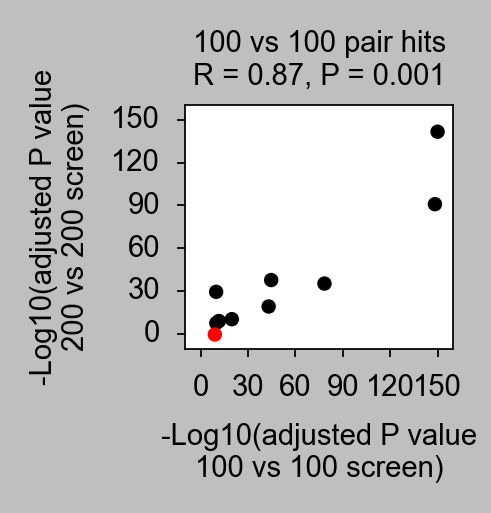

In [ ]:
import numpy as np
from scipy.stats import spearmanr

ax, fig, gs = startfig(4.5, 4.75)

x = -np.log10(comparison_df["P_value_corrected_100_vs_100"])
y = -np.log10(comparison_df["P_value_corrected_200_vs_200"])

ax.scatter(x, y, color=["black" if y_point > 0 else "red" for y_point in y], edgecolors="none", s= 12)

ax.set_ylabel("-Log10(adjusted P value\n200 vs 200 screen)", fontsize = 7)
ax.set_xlabel("-Log10(adjusted P value\n100 vs 100 screen)", fontsize = 7)

ax.set_xlim(-10, 160)
ax.set_ylim(-10, 160)

res = spearmanr(comparison_df["P_value_corrected_100_vs_100"], comparison_df["P_value_corrected_200_vs_200"])

# Bootstrap CI for R (paired resampling)
mask = comparison_df["P_value_corrected_100_vs_100"].notna() & comparison_df["P_value_corrected_200_vs_200"].notna()
x_boot = comparison_df.loc[mask, "P_value_corrected_100_vs_100"].to_numpy()
y_boot = comparison_df.loc[mask, "P_value_corrected_200_vs_200"].to_numpy()

n_boot = 2000
rng = np.random.default_rng(0)
boot_rhos = np.empty(n_boot)
n = len(x_boot)
for i in range(n_boot):
    idx = rng.integers(0, n, n)
    boot_rhos[i] = spearmanr(x_boot[idx], y_boot[idx])[0]

ci_lo, ci_hi = np.nanpercentile(boot_rhos, [2.5, 97.5])
print(f"(95% CI {ci_lo:.2f}–{ci_hi:.2f})")
ax.set_title(f"100 vs 100 pair hits\nR = {round(res[0],2)}, P = {round(res[1], 3)}", fontsize = 7)
ax.set_xticks([x for x in np.arange(0, 160, 30)])
ax.set_yticks([y for y in np.arange(0, 160, 30)])
ax.tick_params('both', top = False, right = False, labelsize = 7)
fig.tight_layout()
fig.savefig('/v1/figures/fig_2_pdfs/comparison_100_vs_100_hit_pvals_with_200_vs_200_pval_scatter.pdf')